In [25]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('/content/drive/MyDrive/data/sierraleone-bumbuna.csv',parse_dates=["Timestamp"])

In [29]:
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-30 12:00:30.000000768,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
min,2021-10-30 00:01:00,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,2022-01-29 06:00:45,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,2022-04-30 12:00:30,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,2022-07-30 18:00:15,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,2022-10-30 00:00:00,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN
std,NaN,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN


In [30]:
missing_report = df.isna().sum().to_frame("missing_count")
missing_report["missing_percent"] = 100 * missing_report["missing_count"] / len(df)
missing_report

,missing_count,missing_percent
Timestamp,0,0.0
GHI,0,0.0
DNI,0,0.0
DHI,0,0.0
ModA,0,0.0
ModB,0,0.0
Tamb,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


In [31]:
#columns with >5% nulls
cols_5 = missing_report[missing_report["missing_percent"] > 5].index.tolist()
print("Columns with >5% nulls:", cols_5)

Columns with >5% nulls: ['Comments']


In [32]:
key_cols = ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"]
key_cols = [c for c in key_cols if c in df.columns]

In [33]:
#Compute Z-scores
for c in key_cols:
    df[c+"_z"] = stats.zscore(df[c].astype(float), nan_policy='omit')

In [34]:
# Flag outliers (|Z|>3)
df["is_outlier"] = (df[[c+"_z" for c in key_cols]].abs() > 3).any(axis=1)
print("Outliers detected:", df["is_outlier"].sum())

Outliers detected: 16292


In [35]:
# Median imputation for key columns
for c in key_cols:
    df[c] = df[c].fillna(df[c].median())

In [36]:
# Export cleaned CSV (never commit this file)
df.to_csv("data/togo_clean.csv", index=False)

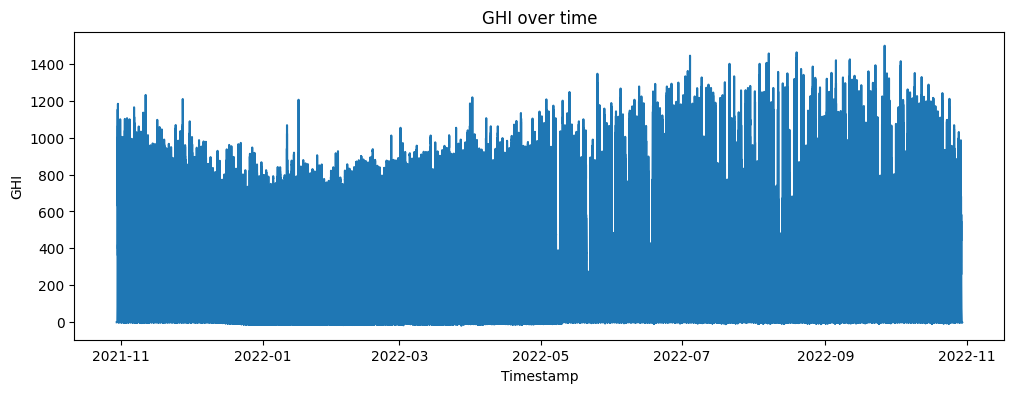

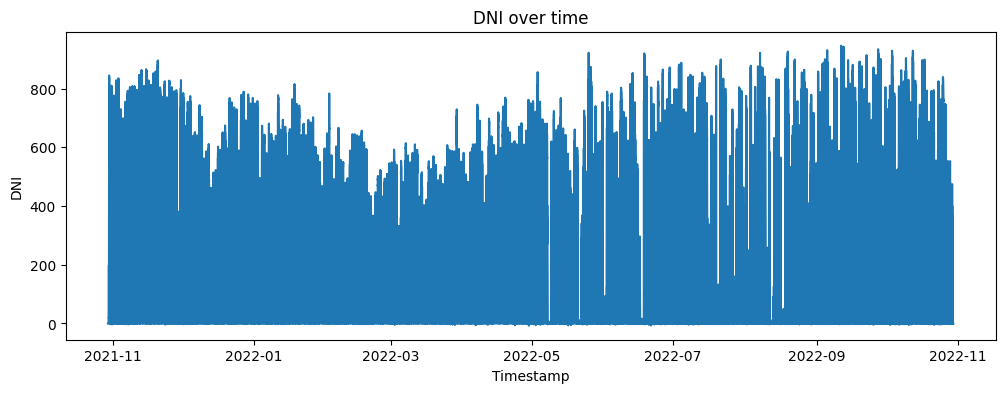

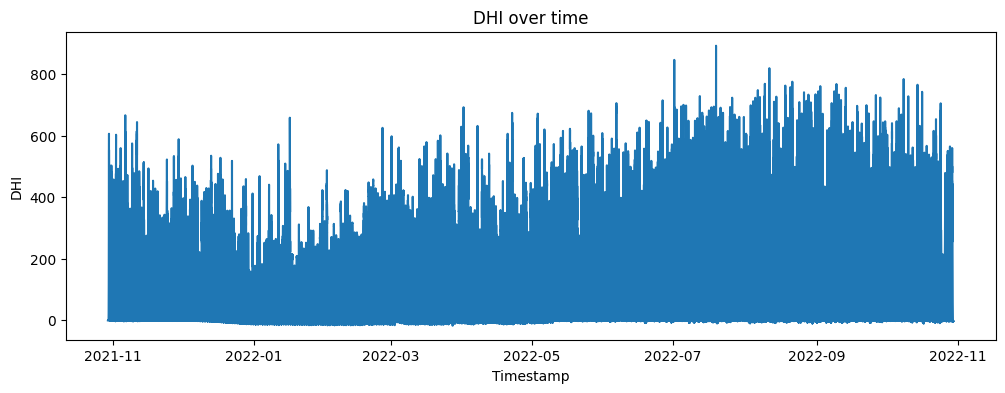

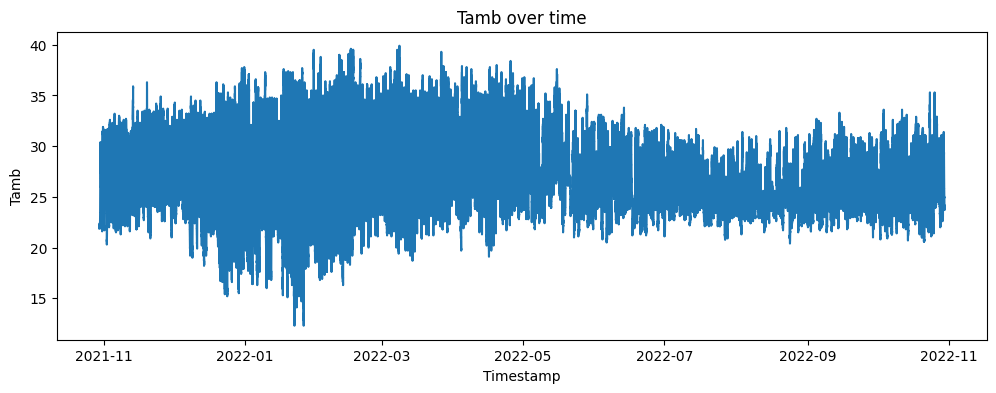

In [37]:
#Time Series Analysis
import matplotlib.pyplot as plt

plot_vars = ["GHI","DNI","DHI","Tamb"]
for col in plot_vars:
    if col in df.columns:
        plt.figure(figsize=(12,4))
        plt.plot(df["Timestamp"], df[col])
        plt.title(f"{col} over time")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.show()


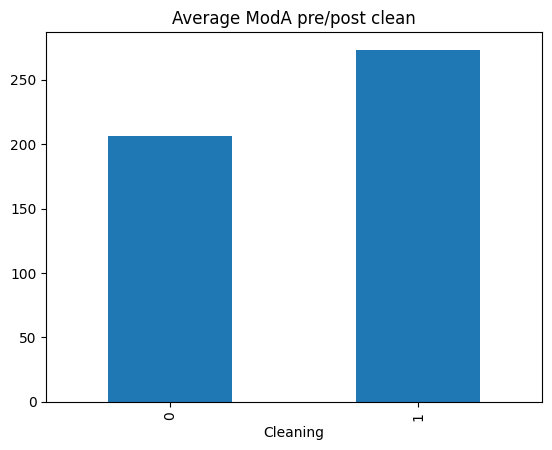

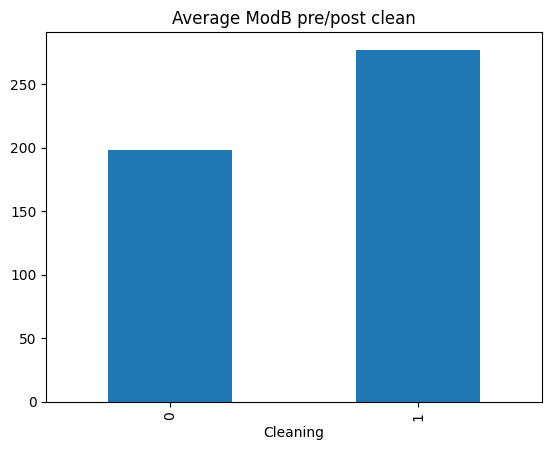

In [38]:
#Cleaning Impact (pre vs post clean)
for col in ["ModA","ModB"]:
    if col in df.columns:
        avg = df.groupby("Cleaning")[col].mean()
        avg.plot(kind="bar", title=f"Average {col} pre/post clean")
        plt.show()


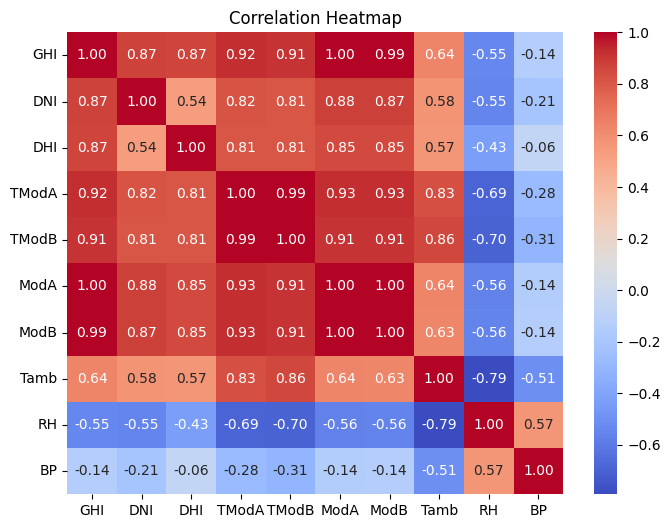

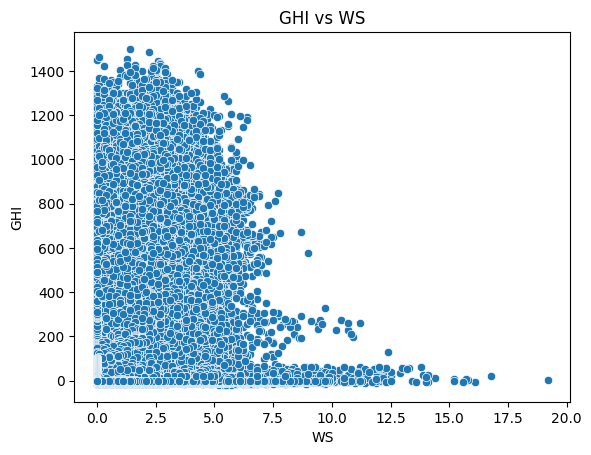

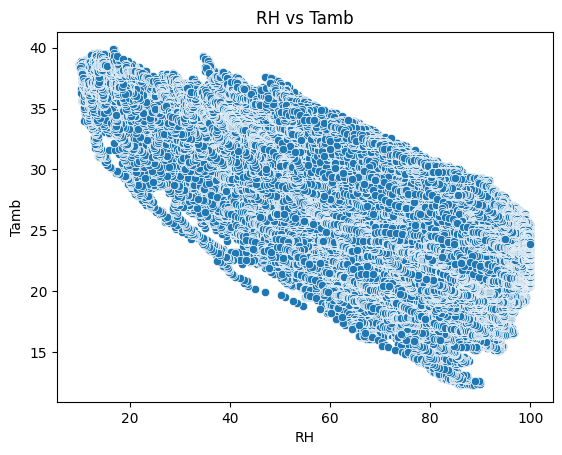

In [39]:
#Correlation & Relationship Analysis


corr_cols = ["GHI","DNI","DHI","TModA","TModB","ModA","ModB","Tamb","RH","BP"]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


sns.scatterplot(data=df, x="WS", y="GHI")
plt.title("GHI vs WS")
plt.show()

sns.scatterplot(data=df, x="RH", y="Tamb")
plt.title("RH vs Tamb")
plt.show()


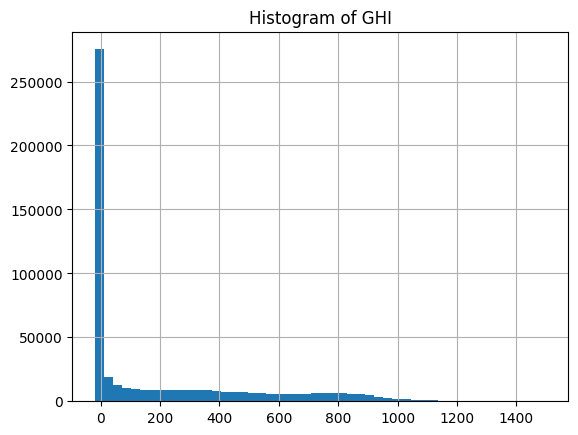

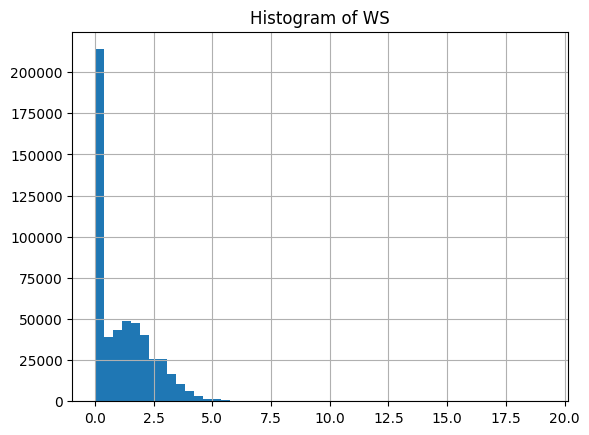

In [40]:
#Wind & Distribution Analysis
df["GHI"].hist(bins=50)
plt.title("Histogram of GHI")
plt.show()

df["WS"].hist(bins=50)
plt.title("Histogram of WS")
plt.show()


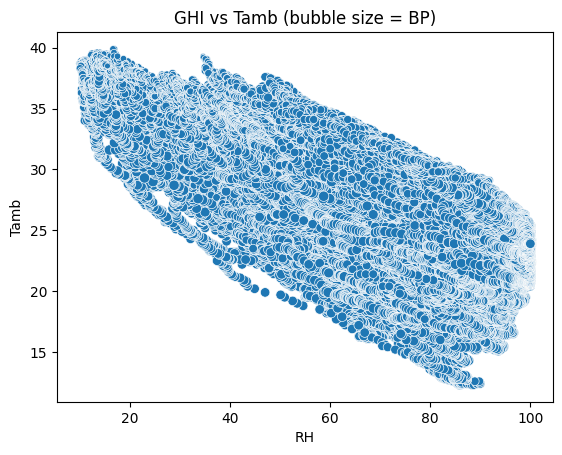

In [41]:
#Temperature Analysis (RH vs Tamb / GHI)
sns.scatterplot(data=df, x="RH", y="Tamb", size="BP", legend=False)
plt.title("GHI vs Tamb (bubble size = BP)")
plt.show()


/tmp/ipython-input-2435093286.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


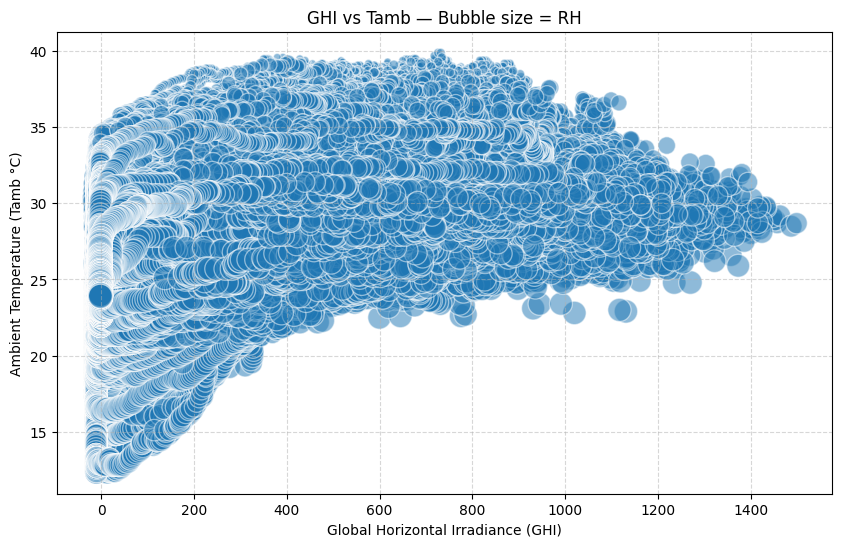

In [42]:
bubble_size_col = "RH"

if all(col in df.columns for col in ["GHI", "Tamb", bubble_size_col]):
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=df,
        x="GHI",
        y="Tamb",
        size=bubble_size_col,
        sizes=(20, 300),
        alpha=0.5,
        palette="viridis",
        legend=False
    )
    plt.title(f"GHI vs Tamb — Bubble size = {bubble_size_col}")
    plt.xlabel("Global Horizontal Irradiance (GHI)")
    plt.ylabel("Ambient Temperature (Tamb °C)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
else:
    print("⚠️ Missing one of: GHI, Tamb, or chosen bubble variable (RH/BP)")
